In [1]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open("./data_sets/revenue-share-price.csv") as file:
    df = pd.read_csv(file)

print(df.head())

      revenue  share price
0  814.723686  8252.090762
1  905.791937  9194.169617
2  126.986816  1410.401597
3  913.375856  9769.189359
4  632.359246  6574.008550


(1000, 1) (1000, 1)


Text(0, 0.5, 'Share Price')

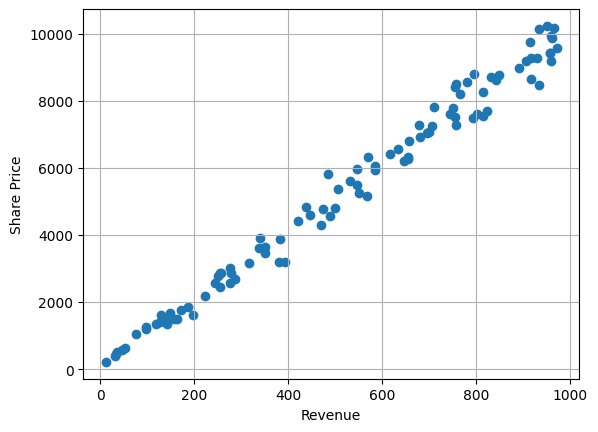

In [7]:
x = np.array(df["revenue"]).reshape(-1, 1)
y = np.array(df["share price"]).reshape(-1,1)
print(x.shape, y.shape)

x_train = x[0:100]
y_train = y[0:100]

plt.scatter(x_train, y_train)
plt.grid(1)
plt.xlabel("Revenue")
plt.ylabel("Share Price")

[73.62659811] [[10.06082494]]


Text(0, 0.5, 'Share Price')

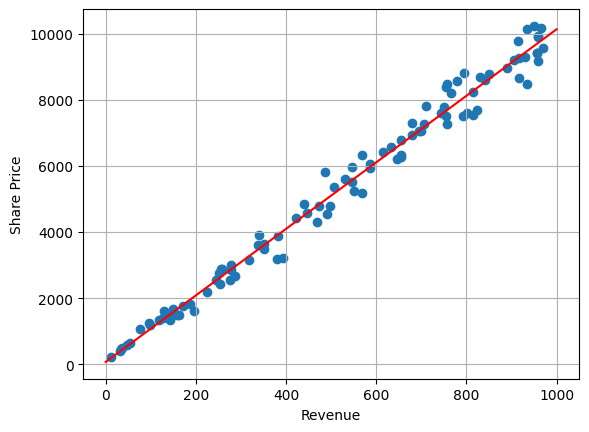

In [10]:
model = LinearRegression()
model.fit(x_train, y_train)
print(model.intercept_, model.coef_)

x_plot = [[0], [1000]]
y_plot = model.predict(x_plot)

plt.scatter(x_train, y_train)
plt.plot(x_plot, y_plot, "r")
plt.grid(1)
plt.xlabel("Revenue")
plt.ylabel("Share Price")

In [14]:
x_test = x[100:]
y_test = y[100:]
y_predict = model.predict(x_test)

# Let us display the first 5 smaples from the test set x, y, and predicted y
test_first_5 = np.hstack((x_test[0:5], y_test[0:5], y_predict[0:5]))  # Horizontally stacks arrays
print(test_first_5)
print(model.score(x_test, y_test))  # R^2 score

[[ 162.1823082  1581.40783    1705.31440849]
 [ 794.2845407  7722.835157   8064.78431083]
 [ 311.215042   3050.544153   3204.70665287]
 [ 528.5331355  5311.090205   5391.10594683]
 [ 165.6487295  1648.672453   1740.18946635]]
0.9816024564155313


Car MPG Example

   car   mpg  cyl  displ   hp  weight  accel  yr origin  \
0    0  18.0    8  307.0  130    3504   12.0  70     US   
1    1  15.0    8  350.0  165    3693   11.5  70     US   
2    2  18.0    8  318.0  150    3436   11.0  70     US   
3    3  16.0    8  304.0  150    3433   12.0  70     US   
4    4  17.0    8  302.0  140    3449   10.5  70     US   

                        name  
0  chevrolet chevelle malibu  
1          buick skylark 320  
2         plymouth satellite  
3              amc rebel sst  
4                ford torino  


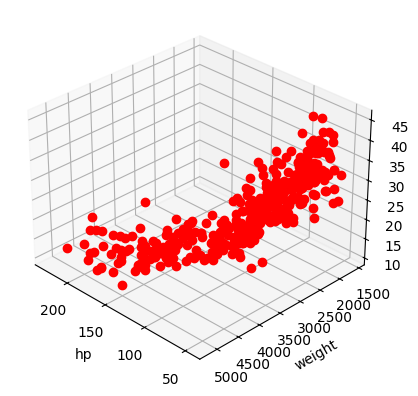

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import axes3d

with open("./data_sets/car_mpg.csv") as file:
    df = pd.read_csv(file)

print(df.head())

y = df["mpg"]
x1 = df["hp"]
x2 = df["weight"]

ax = plt.axes(projection = "3d")
ax.plot3D(x1, x2, y, "ro")
plt.xlabel("hp")
plt.ylabel("weight")
ax.view_init(30,135)


In [21]:
print(x1.shape, x2.shape)
x = np.array([x1, x2]).T
print(x.shape)
y = np.array(y).reshape(-1,1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33)
model = LinearRegression()
model.fit(x_train, y_train)
print(model.intercept_, model.coef_)
print(model.score(x_train, y_train))
print(model.score(x_test, y_test))


(392,) (392,)
(392, 2)
[45.02935968] [[-0.03732453 -0.00596434]]
0.6978861242694925
0.7165191038259018
